# Jacobi Iteration and Conjugate Gradient

We solve $Ax=b$ by starting with a guess and refining it. This is necessary when $A$ is too large to factorize (LU or Cholesky).

- **Jacobi:** Splitting the matrix into easy and hard parts.
- **Conjugate Gradient (CG):** Minimizing the "energy" of the system.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sparse
import scipy.sparse.linalg as spla

## 1. Jacobi

Split $A = D + R$, where $D$ is the diagonal and $R$ is everything else.
$$Ax = b \implies (D + R)x = b \implies Dx = b - Rx$$

The update rule is:
$$x^{(k+1)} = D^{-1}(b - Rx^{(k)})$$

**The Condition:** This converges if the **spectral radius** of the iteration matrix $T_J = -D^{-1}R$ is less than 1.

**Geometric Interpretation:** Each row of $Ax=b$ is a line. Their intersection is the exact solution $x_*$, and Jacobi builds iterates that move toward that intersection.


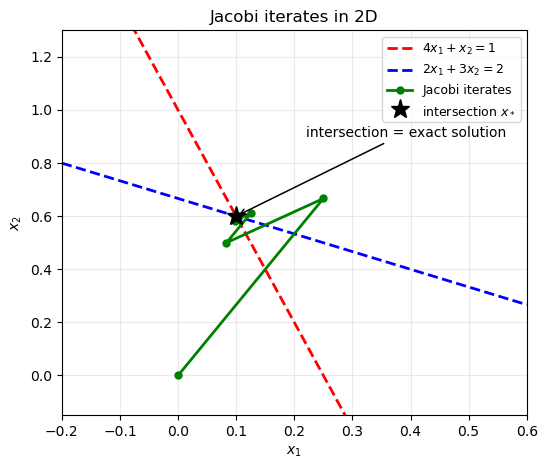

In [2]:
def jacobi_path(A, b, x0, steps):
    d = np.diag(A)
    R = A - np.diag(d)
    x = x0.astype(float)
    xs = [x.copy()]
    for _ in range(steps):
        x = (b - R @ x) / d
        xs.append(x.copy())
    return np.array(xs)

A = np.array([[4., 1.], [2., 3.]])
b = np.array([1., 2.])
xs = jacobi_path(A, b, np.array([0., 0.]), 8)
x_star = np.linalg.solve(A, b)
x = np.linspace(-0.2, 0.6, 300)
lines = [
    ((b[0] - A[0, 0] * x) / A[0, 1], 'r--', r'$4x_1 + x_2 = 1$'),
    ((b[1] - A[1, 0] * x) / A[1, 1], 'b--', r'$2x_1 + 3x_2 = 2$'),
]

fig, ax = plt.subplots(figsize=(6, 5))
for y, style, label in lines:
    ax.plot(x, y, style, lw=2, label=label)
ax.plot(xs[:, 0], xs[:, 1], 'go-', lw=2, ms=5, label='Jacobi iterates')
ax.plot(*x_star, 'k*', ms=14, label=r'intersection $x_*$')
ax.annotate('intersection = exact solution', x_star, xytext=(0.22, 0.9),
            arrowprops=dict(arrowstyle='->', lw=1.1), fontsize=10)
ax.set(xlabel=r'$x_1$', ylabel=r'$x_2$', title='Jacobi iterates in 2D', xlim=(-0.2, 0.6), ylim=(-0.15, 1.3))
ax.grid(alpha=0.25)
ax.legend(fontsize=9)
plt.show()

## 2. Conjugate Gradient

For SPD $A$, solving $Ax = b$ is equivalent to minimizing
$$\phi(x) = \tfrac12 x^T A x - b^T x.$$
Contours are ellipses; $x_*$ is the center.

**$A$-conjugate directions.** $p$ and $q$ are *$A$-conjugate* if $p^T A q = 0$, i.e., orthogonal in the inner product $\langle u, v\rangle_A = u^TAv$. Minimizing $\phi$ along $p$ does not disturb the error component along any $A$-conjugate $q$. With $n$ mutually $A$-conjugate directions in $\mathbb{R}^n$, CG reaches $x_*$ in exactly $n$ steps.

**Steepest descent (or gradient descent)** sets $p_k = r_k$. Consecutive residuals satisfy $r_k^T r_{k-1} = 0$ but $r_k^T A r_{k-1} \neq 0$: $r_k$ is orthogonal but not $A$-conjugate to $r_{k-1}$, so stepping along $r_k$ reintroduces error in the $r_{k-1}$ direction.

**CG** corrects $r_k$ into an $A$-conjugate direction. From $p_0 = r_0$:
$$p_k = r_k + \beta_{k-1}\,p_{k-1}, \qquad \beta_{k-1} = \frac{r_k^T r_k}{r_{k-1}^T r_{k-1}},$$
$$\alpha_k = \frac{r_k^T r_k}{p_k^T A p_k}, \qquad x_{k+1} = x_k + \alpha_k p_k.$$
$\beta_{k-1}$ is the unique scalar satisfying $p_k^T A p_{k-1} = 0$.

### Step-by-step: 2D example ($n = 2$, minimizer at origin)

CG reaches $x_*$ in exactly $n = 2$ steps.

In [3]:
A = np.array([[10., 4.],
              [ 4., 3.]])
b = np.array([0., 0.])
x0 = np.array([-1.6, 1.2])

r0 = b - A @ x0
p0 = r0.copy()
a0 = (r0 @ r0) / (p0 @ (A @ p0))
x1 = x0 + a0 * p0
r1 = b - A @ x1
print(f"k=0  alpha0={a0:.6f}  x1={x1}")

beta0 = (r1 @ r1) / (r0 @ r0)
p1 = r1 + beta0 * p0        # beta0 chosen so p0^T A p1 = 0
a1 = (r1 @ r1) / (p1 @ (A @ p1))
x2 = x1 + a1 * p1
print(f"k=1  beta0={beta0:.6f}  alpha1={a1:.6f}  x2={x2}")
print(f"     p0^T A p1 = {p0 @ (A @ p1):.2e}")

x = x0.copy()
xs_sd = [x.copy()]
for _ in range(5):
    r = b - A @ x
    a = (r @ r) / (r @ (A @ r))
    x = x + a * r
    xs_sd.append(x.copy())
xs_sd = np.array(xs_sd)

k=0  alpha0=0.087179  x1=[-0.62358974  1.44410256]
k=1  beta0=0.026930  alpha1=0.819328  x2=[-3.33066907e-16  0.00000000e+00]
     p0^T A p1 = -6.50e-14


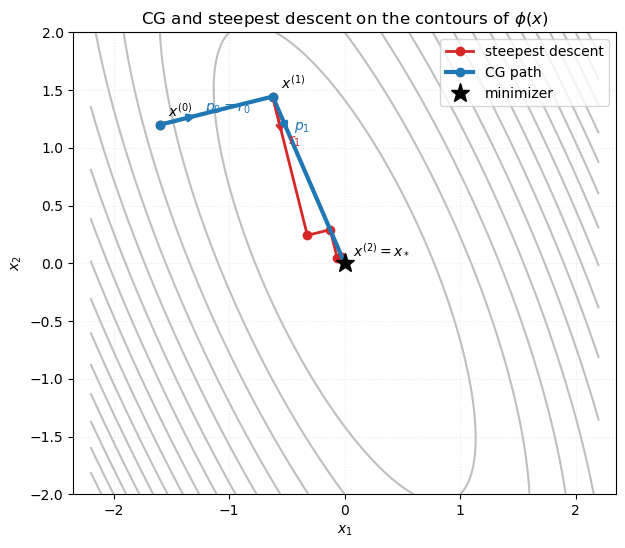

In [4]:
def u(v, s=0.35):
    return s * v / np.linalg.norm(v)

pts = np.array([x0, x1, x2])
arrows = [
    (x0, p0, r'$p_0=r_0$', 'tab:blue', (0.05, 0.03)),
    (x1, r1, r'$r_1$', 'tab:red', (0.05, -0.08)),
    (x1, p1, r'$p_1$', 'tab:blue', (0.05, 0.03)),
]
labels = [r'$x^{(0)}$', r'$x^{(1)}$', r'$x^{(2)}=x_*$']

x = np.linspace(-2.2, 2.2, 300)
y = np.linspace(-2.0, 2.0, 300)
X, Y = np.meshgrid(x, y)
Z = 0.5 * (A[0, 0] * X**2 + 2 * A[0, 1] * X * Y + A[1, 1] * Y**2)

fig, ax = plt.subplots(figsize=(7, 6))
ax.contour(X, Y, Z, levels=16, colors='0.75')
ax.plot(xs_sd[:, 0], xs_sd[:, 1], 'o-', color='tab:red', lw=2, label='steepest descent')
ax.plot(pts[:, 0], pts[:, 1], 'o-', color='tab:blue', lw=3, label='CG path')
ax.plot(0, 0, 'k*', ms=14, label='minimizer')

for base, vec, text, color, shift in arrows:
    tip = base + u(vec)
    ax.annotate('', tip, base, arrowprops=dict(arrowstyle='->', color=color, lw=2.5 if color == 'tab:blue' else 2))
    ax.text(*(tip + np.array(shift)), text, color=color)

for pt, text in zip(pts, labels):
    ax.annotate(text, pt, xytext=(6, 6), textcoords='offset points')

ax.set(xlabel=r'$x_1$', ylabel=r'$x_2$', title=r'CG and steepest descent on the contours of $\phi(x)$')
ax.axis('equal')
ax.grid(alpha=0.25, linestyle=':')
ax.legend()...
plt.show()

## 3. Large Scale Comparison: 1D Poisson Problem

For a large sparse SPD problem, we cannot draw the full bowl anymore, but we can still track the same quadratic loss
$$\phi(x) = \frac{1}{2}x^T A x - b^T x.$$

Below, the residual plot shows convergence in the usual way, and the loss plot shows the same comparison directly in terms of the energy being minimized.


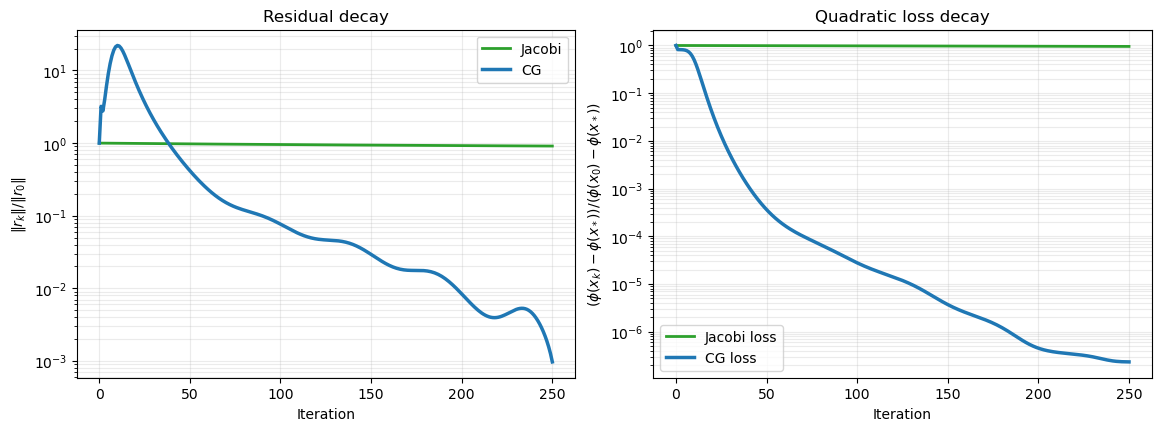

In [5]:
def energy(A, b, x):
    return 0.5 * x @ (A @ x) - b @ x

def jacobi_hist(A, b, steps, x_star):
    d = A.diagonal()
    R = A - sparse.diags(d)
    x = np.zeros(A.shape[0])
    p_star = energy(A, b, x_star)
    p0 = energy(A, b, x)
    rs = [np.linalg.norm(b - A @ x)]
    es = [p0 - p_star]
    for _ in range(steps):
        x = (b - R @ x) / d
        rs.append(np.linalg.norm(b - A @ x))
        es.append(max(energy(A, b, x) - p_star, 1e-30))
    return np.array(rs), np.array(es)

def cg_hist(A, b, steps, x_star):
    x = np.zeros(A.shape[0])
    r = b.copy()
    p = r.copy()
    rr = r @ r
    p_star = energy(A, b, x_star)
    p0 = energy(A, b, x)
    rs = [np.sqrt(rr)]
    es = [p0 - p_star]
    for _ in range(steps):
        Ap = A @ p
        a = rr / (p @ Ap)
        x = x + a * p
        r = r - a * Ap
        rr_new = r @ r
        rs.append(np.sqrt(rr_new))
        es.append(max(energy(A, b, x) - p_star, 1e-30))
        if rr_new < 1e-14:
            break
        p = r + (rr_new / rr) * p
        rr = rr_new
    return np.array(rs), np.array(es)

n = 500
A = sparse.diags([-1, 2, -1], [-1, 0, 1], shape=(n, n), format='csr')
x = np.linspace(0, 1, n)
b = np.sin(2 * np.pi * x) + 0.5 * np.sin(11 * np.pi * x)
x_star = spla.spsolve(A, b)
rj, ej = jacobi_hist(A, b, 3000, x_star)
rc, ec = cg_hist(A, b, n, x_star)
window = 250
specs = [
    (rj, rc, 'Residual decay', r'$\|r_k\|/\|r_0\|$', 'Jacobi', 'CG'),
    (ej, ec, 'Quadratic loss decay', r'$(\phi(x_k)-\phi(x_*))/(\phi(x_0)-\phi(x_*))$', 'Jacobi loss', 'CG loss'),
]

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.2), constrained_layout=True)
for a, (y1, y2, title, ylabel, l1, l2) in zip(ax, specs):
    for y, color, lw, label in [(y1, 'tab:green', 2, l1), (y2, 'tab:blue', 2.5, l2)]:
        a.semilogy(y[:window + 1] / y[0], color=color, lw=lw, label=label)
    a.set(title=title, xlabel='Iteration', ylabel=ylabel)
    a.grid(True, which='both', alpha=0.25)
    a.legend()
plt.show()